In [1]:
%matplotlib widget
# Boilerplate import code for all libraries
# Changes to the precision require re-loading the kernel and need to be done before any op uses them.
import sphWarpCore_config as swc
from typing import Any
swc.configure(precision="float32", dim=Any) # precision: float16|half|float32|single|float64|double

import sphWarpCore as sph
from sphWarpCore.type_config import *
print(get_type_config()) # confirms active settings

# Initialize warp at this point
import warp as wp; wp.init()

import os
import torch
if torch.cuda.is_available(): # set the TORCH_CUDA_ARCH_LIST environment variable to the compute capability of the GPU for faster compiles
    os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm

# final import blocks that are generic
import matplotlib.pyplot as plt
from torch.profiler import profile, record_function, ProfilerActivity
import numpy as np
import math
import shlex    
import subprocess
import shutil

# custom SPH libraries
from integrators.integration import *
from sphWarpCore import *
from warpPlot import *

# This library
from warpSPH import *

# The case utilities that contain all the case setup functions for the various test cases
from warpSPH.caseUtils import *

{'scalar_t': <class 'warp._src.types.float32'>, 'dim_t': typing.Any}
Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:
nx = 256
dim = 2
L = 2 * np.pi
n_h = 4
targetDt = 0.001

gamma = 5/3
rho0 = 1
nu_visc = 0.0005
freeSurface = False

extraData = {
    'nx': nx,
    'dim': dim,
    'L': L,
    'n_h': n_h,

    'gamma': gamma,
    'rho0': rho0,
    'nu_visc': nu_visc,
}

In [3]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = get_torch_precision()

domain = buildDomainDescription(L, dim, True, device, dtype)
domain.min = torch.zeros(dim, device=device, dtype=dtype)
domain.max = torch.ones(dim, device=device, dtype=dtype) * 2 * np.pi
interiorDomain = domain

config, integrator = buildConfig(
    domain = domain,
    dim = dim,
    kernel = KernelFunctions.Wendland4,
    targetNeighbors = n_h_to_nH(4, dim),
    supportMode = SupportScheme.KernelMeanSymmetric,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta2,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = None,
    adaptiveDt = True,
    cflFactor=0.3,
)
config.nx = nx

config.minDt = 1e-8
# config.dx = L / (nx * 2)

scheme = WeaklyCompressibleSPHScheme.deltaSPH
SimulationSystem, SimulationState, SimulationConfig, SimulationUpdate, fn, export_fn, import_fn = buildScheme(scheme)


schemeConfig = SimulationConfig()
schemeConfig.surfaceDetectionConfig.active = freeSurface


In [4]:

fluid_sdf = lambda x: sampleDomainSDF(x, domain, invert = True)
regions = []

regions.append(buildRegion(config, schemeConfig, fluid_sdf, RegionType.Fluid, initialConditions = {}))

for region in regions:
    region = filterRegion(region, regions)

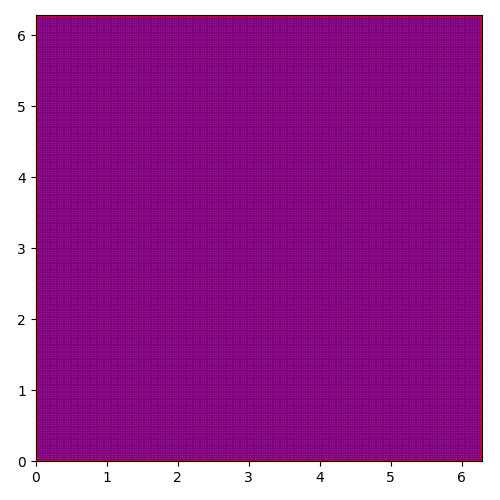

In [5]:
fig, axis = plt.subplots(1, 1, figsize=(5, 5), squeeze=False)
plotRegions(regions, axis[0,0], plotFluid = True, plotParticles = True)

rectangle = plt.Rectangle((domain.min[0].cpu().numpy(), domain.min[1].cpu().numpy()), domain.max[0].cpu().numpy() - domain.min[0].cpu().numpy(), domain.max[1].cpu().numpy() - domain.min[1].cpu().numpy(), fill=False, color='black', lw=2)
axis[0,0].add_patch(rectangle)

rectangleInterior = plt.Rectangle((interiorDomain.min[0].cpu().numpy(), interiorDomain.min[1].cpu().numpy()), interiorDomain.max[0].cpu().numpy() - interiorDomain.min[0].cpu().numpy(), interiorDomain.max[1].cpu().numpy() - interiorDomain.min[1].cpu().numpy(), fill=False, color='red', lw=2)
axis[0,0].add_patch(rectangleInterior)

import matplotlib.patches as patches

for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(domain.min[0].item(), domain.max[0].item())
    ax.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()

In [6]:
compressibleSystem = setupBasicWeaklyCompressibleInitialState(nx, config, schemeConfig, SimulationState, SimulationSystem)
compressibleSystem.state.positions = shuffleParticles(compressibleSystem.state, config, schemeConfig, 32, jitterAmount = 1.0)


k = 2
u_mag = 1
k_ = k

ktgv = k_ / 2
if k_ % 2 == 0:
    phaseShift_x = np.pi / 2# / k
    phaseShift_y = np.pi / 2# / k
else:
    phaseShift_x = 0
    phaseShift_y = 0

compressibleSystem.state.velocities[:,0] =  u_mag * torch.cos(ktgv * compressibleSystem.state.positions[:,0] + phaseShift_x) * torch.sin(ktgv *  compressibleSystem.state.positions[:,1] + phaseShift_y)
compressibleSystem.state.velocities[:,1] = -u_mag * torch.sin(ktgv * compressibleSystem.state.positions[:,0] + phaseShift_x) * torch.cos(ktgv * compressibleSystem.state.positions[:,1] + phaseShift_y)



schemeConfig.fluid.fixedSoundSpeed, config.dt = setupWeaklyCompressibleTimestep(config, schemeConfig, compressibleSystem, targetDt, verbose = True)
print(f"Computed timestep: {config.dt:.6g}, target timestep: {targetDt:.6g}, diff: {abs(config.dt - targetDt):.6g}")

Module sphWarpCore.radiusSearch.wp_compactHash e67fccd load on device 'cuda:0' took 5.12 ms  (cached)
Module sphWarpCore.operations_grid.wp_density_grid d6cfc50 load on device 'cuda:0' took 5.98 ms  (cached)
Module warpSPH.sample.wp_deltaShift 5178276 load on device 'cuda:0' took 6.12 ms  (cached)
Computed c0: 13.564805030822754, target c0: 10.0, diff: 3.564805030822754
Computed dt: 0.0010000000474974513, target dt: 0.001, diff: 0.0
Max velocity: 0.9999805688858032, CFL: 0.04074287414550781, Max Mach: 0.07371875643730164
Computed timestep: 0.001, target timestep: 0.001, diff: 0


In [7]:
ke0 = compressibleSystem.state.masses * torch.linalg.norm(compressibleSystem.state.velocities, dim=1)**2 * 0.5
m_total = compressibleSystem.state.masses.sum().cpu().item()
# kineticEnergy = np.array([ke.cpu().item() for ke in kes]).sum()

domainL = config.domain.max[0].cpu().item() - config.domain.min[0].cpu().item()
Ek0_theoretical = 0.25 * u_mag**2 * schemeConfig.fluid.restDensity * domainL**2
print(f"Theoretical initial kinetic energy: {Ek0_theoretical:.6g}")
print(f"Initial kinetic energy from simulation: {ke0.sum().cpu().item():.6g}")
print(f'Difference: {abs(Ek0_theoretical - ke0.sum().cpu().item()):.6g}')

Theoretical initial kinetic energy: 9.8696
Initial kinetic energy from simulation: 9.86194
Difference: 0.00766457


In [8]:
runningState = compressibleSystem.initializeNewState()


In [9]:
particles = runningState.state
dt = config.dt

adjacency = buildVerletList(
    particles, 
    config.domain, verletScale = 1.0, supportMode = SupportScheme.SuperSymmetric,
    priorNeighborhood = None,
    verbose = False)

dvdt = torch.zeros_like(particles.velocities, device=config.device, dtype=config.dtype)


In [10]:
from warpSPH.configurations import SimulationConfig
from typing import Optional, Union, Any

def computeDivergenceIISPH(
        currentState: Any, 
        config: SimulationConfig, 
        schemeConfig: Any, 
        adjacency: Optional[Union[AdjacencyList, CompactHashMap]], 
        advectionVelocities: torch.Tensor        
):
        # drhodt can be computed either using the current densities or the rest density
        # the latter is the option chosen in dfsph

    return - schemeConfig.fluid.restDensity * warpOperation(
                currentState,
                OperationProperties(
                        kernel = config.kernel,
                        operation = WarpOperation.Divergence,
                        gradientMode = GradientScheme.Difference,
                        supportMode = SupportScheme.Scatter,
                ),
                queryValues = advectionVelocities,
                domain = config.domain,
                adjacency=adjacency,
                consistentDivergence = False,
        )       

from warpSPH.configurations import SimulationConfig
from typing import Optional

def computePressureAccelIISPH(
    state: CompressibleState,
    pressureValues: torch.Tensor,
    config: SimulationConfig,
    supportScheme: SupportScheme = SupportScheme.Scatter,
    adjacency: Optional[AdjacencyList] = None):
    return -warpOperation(
        state,
        OperationProperties(
            kernel = config.kernel,
            operation = WarpOperation.Gradient,
            gradientMode = GradientScheme.Summation,
            supportMode = supportScheme,
        ),
        queryValues = pressureValues,
        domain = config.domain,
        adjacency=adjacency,
    ) / state.densities[:, None]

def computePressureShiftIISPH(
    state: CompressibleState,
    config: SimulationConfig,
    pressureAccels: torch.Tensor,
    supportScheme: SupportScheme = SupportScheme.Scatter,
    adjacency: Optional[AdjacencyList] = None,):
    dt = config.dt
    kernelSum = warpOperation(
        state,
        OperationProperties(
            kernel = config.kernel,
            operation = WarpOperation.Divergence,
            gradientMode = GradientScheme.Difference,
            supportMode = SupportScheme.Scatter,
        ),
        queryValues = pressureAccels,
        domain = config.domain,
        adjacency=adjacency,
        consistentDivergence = False, # Computes fj - fi, (9) in PBSPH states fi -fj thus the minus sign
    ) #* state.densities
    return -dt**2 * kernelSum

from wp_alpha import computeAlpha

Predicted velocities: mean: -6.11517e-05, min: -0.999981, max: 0.999979
Apparent area: 0.000602393, min: 0.000602393, max: 0.000602393
Module sphWarpCore.operations.wp_divergence a5da11f load on device 'cuda:0' took 10.97 ms  (cached)
Source term: -8.73388e-09, min: -5.94854e-05, max: 6.44326e-05
Module wp_alpha 51fd7c3 load on device 'cuda:0' took 8.97 ms  (cached)
Alpha: -0.000163013, min: -0.000197337, max: -0.000127645
Module sphWarpCore.operations.wp_gradient 77e4101 load on device 'cuda:0' took 9.09 ms  (cached)
Iteration 1/32, error: 4.45009e-06, pressure min/max/mean: (-0.12646281719207764, 0.11896705627441406, 2.149394276784733e-05)
Iteration 2/32, error: 3.91717e-06, pressure min/max/mean: (-0.19861724972724915, 0.20077845454216003, 4.225085649522953e-05)
Iteration 3/32, error: 3.72101e-06, pressure min/max/mean: (-0.2718934416770935, 0.27293190360069275, 6.27859917585738e-05)
Iteration 4/32, error: 3.59091e-06, pressure min/max/mean: (-0.35939425230026245, 0.3374454379081726

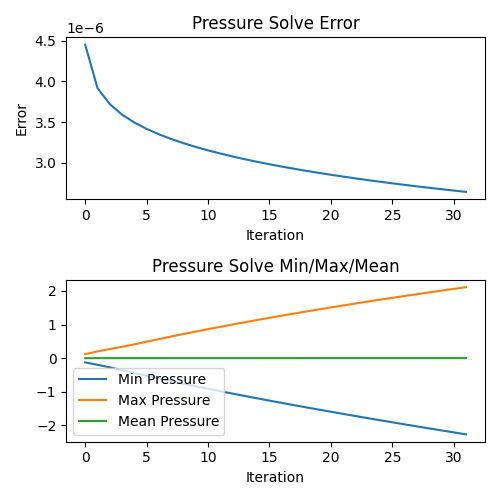

In [11]:
predictedVelocities = particles.velocities + dt * dvdt

print(f'Predicted velocities: mean: {predictedVelocities.mean().cpu().item():.6g}, min: {predictedVelocities.min().cpu().item():.6g}, max: {predictedVelocities.max().cpu().item():.6g}')

apparentArea = particles.masses / particles.densities    

print(f'Apparent area: {apparentArea.mean().cpu().item():.6g}, min: {apparentArea.min().cpu().item():.6g}, max: {apparentArea.max().cpu().item():.6g}')

divergence = computeDivergenceIISPH(
    currentState = particles, 
    config = config, 
    schemeConfig = schemeConfig, 
    adjacency = adjacency, 
    advectionVelocities = predictedVelocities
)

sourceTerm = config.dt * divergence

rho0 = schemeConfig.fluid.restDensity
rhoStar = particles.densities + config.dt * divergence

# sourceTerm = config.dt * divergence
sourceTerm = (rho0 - rhoStar) #/ config.dt

print(f'Source term: {sourceTerm.mean().cpu().item():.6g}, min: {sourceTerm.min().cpu().item():.6g}, max: {sourceTerm.max().cpu().item():.6g}')

alphas = computeAlpha(
    currentState = particles,
    config = config,
    schemeConfig = schemeConfig,
    adjacency = adjacency,
    apparentVolumes = apparentArea,
)

print(f'Alpha: {alphas.mean().cpu().item():.6g}, min: {alphas.min().cpu().item():.6g}, max: {alphas.max().cpu().item():.6g}')
pressureA = particles.pressures.clone() * 0.75
pressureB = pressureA.clone()

errors = []
pressures = []
i = 0
error = 0.
minIters = 2
maxIters = 32
threshold = 1e-3
omega = 0.3

for i in range(maxIters):
    pressureA = pressureB.clone()
    a_p = computePressureAccelIISPH(
        state = particles,
        pressureValues = pressureA,
        config = config,
        supportScheme = SupportScheme.Scatter,
        adjacency = adjacency,
    )
    dx_p = computePressureShiftIISPH(
        state = particles,
        config = config,
        pressureAccels = a_p,
        supportScheme = SupportScheme.Scatter,
        adjacency = adjacency,
    )

    residual = sourceTerm - dx_p
    pressureB = pressureA + omega * residual / alphas

    error = torch.mean(torch.abs(residual)).cpu().item()
    errors.append(error)

    pressures.append((pressureB.min().cpu().item(), pressureB.max().cpu().item(), pressureB.mean().cpu().item()))

    print(f"Iteration {i+1}/{maxIters}, error: {error:.6g}, pressure min/max/mean: {pressures[-1]}")

fig, axis = plt.subplots(2, 1, figsize=(5, 5), squeeze=False)

axis[0,0].plot(errors)
axis[0,0].set_title("Pressure Solve Error")
axis[0,0].set_xlabel("Iteration")
axis[0,0].set_ylabel("Error")

axis[1,0].plot([p[0] for p in pressures], label="Min Pressure")
axis[1,0].plot([p[1] for p in pressures], label="Max Pressure")
axis[1,0].plot([p[2] for p in pressures], label="Mean Pressure")
axis[1,0].set_title("Pressure Solve Min/Max/Mean")
axis[1,0].set_xlabel("Iteration")
axis[1,0].legend()

fig.tight_layout()

In [12]:
from typing import Any, Optional, Union
def solveIncompressible(        
        particles: Any, 
        config: SimulationConfig, 
        schemeConfig: Any, 
        adjacency: Optional[Union[AdjacencyList, CompactHashMap]], 
        dvdt: torch.Tensor        
):
        predictedVelocities = particles.velocities + config.dt * dvdt

        # print(f'Predicted velocities: mean: {predictedVelocities.mean().cpu().item():.6g}, min: {predictedVelocities.min().cpu().item():.6g}, max: {predictedVelocities.max().cpu().item():.6g}')

        apparentArea = particles.masses / particles.densities    

        # print(f'Apparent area: {apparentArea.mean().cpu().item():.6g}, min: {apparentArea.min().cpu().item():.6g}, max: {apparentArea.max().cpu().item():.6g}')

        divergence = computeDivergenceIISPH(
                currentState = particles, 
                config = config, 
                schemeConfig = schemeConfig, 
                adjacency = adjacency, 
                advectionVelocities = predictedVelocities
        )

        rho0 = schemeConfig.fluid.restDensity
        rhoStar = particles.densities + config.dt * divergence

        # sourceTerm = config.dt * divergence
        sourceTerm = (rho0 - rhoStar)# / config.dt

        sourceTerm = sourceTerm - sourceTerm.mean()  # Remove mean to ensure zero-mean source term

        print(f'Source term: {sourceTerm.mean().cpu().item():.6g}, min: {sourceTerm.min().cpu().item():.6g}, max: {sourceTerm.max().cpu().item():.6g}')

        alphas = computeAlpha(
                currentState = particles,
                config = config,
                schemeConfig = schemeConfig,
                adjacency = adjacency,
                apparentVolumes = apparentArea,
        )

        # print(f'Alpha: {alphas.mean().cpu().item():.6g}, min: {alphas.min().cpu().item():.6g}, max: {alphas.max().cpu().item():.6g}')

        pressureA = particles.pressures.clone() * 0.75
        pressureB = pressureA.clone()

        errors = []
        pressures = []
        i = 0
        error = 0.
        minIters = 2
        maxIters = 32
        threshold = 1e-3
        omega = 0.4

        # print(f"Solving for divergence-free velocities with maxIters={maxIters}, threshold={threshold:.6g}, omega={omega:.6g}")

        for i in range(maxIters):
                pressureA = pressureB.clone()
                a_p = computePressureAccelIISPH(
                        state = particles,
                        pressureValues = pressureA,
                        config = config,
                        supportScheme = SupportScheme.Scatter,
                        adjacency = adjacency,
                )
                dx_p = computePressureShiftIISPH(
                        state = particles,
                        config = config,
                        pressureAccels = a_p,
                        supportScheme = SupportScheme.Scatter,
                        adjacency = adjacency,
                )

                residual = sourceTerm - dx_p
                pressureB = pressureA + omega * residual / alphas

                error = torch.mean(torch.abs(residual)).cpu().item()
                errors.append(error)

                pressures.append((pressureB.min().cpu().item(), pressureB.max().cpu().item(), pressureB.mean().cpu().item()))

                if i >= minIters and error < threshold:
                #     print(f"Converged after {i+1} iterations with error: {error:.6g}")
                    break
                

                # print(f"Iteration {i+1}/{maxIters}, error: {error:.6g}, pressure min/max/mean: {pressures[-1]}")

        a_p = computePressureAccelIISPH(
                state = particles,
                pressureValues = pressureB,
                config = config,
                supportScheme = SupportScheme.Scatter,
                adjacency = adjacency,
        )
        # print(f"Final pressure acceleration: mean: {a_p.mean().cpu().item():.6g}, min: {a_p.min().cpu().item():.6g}, max: {a_p.max().cpu().item():.6g}")

        print(f'final Residual: {residual.mean().cpu().item():.6g}, min: {residual.min().cpu().item():.6g}, max: {residual.max().cpu().item():.6g}')

        return a_p, pressureB, errors, pressures

In [13]:
config.dt = 1e-3
runningState = compressibleSystem.initializeNewState()
# runningState.state.velocities = torch.zeros_like(runningState.state.velocities, device=config.device, dtype=config.dtype)
adjacency = None

trajectories = []
adjacency = buildVerletList(
    runningState.state, 
    config.domain, verletScale = 1.4, supportMode = SupportScheme.SuperSymmetric,
    priorNeighborhood = adjacency,
    verbose = False)
rhoInit = computeDensities(runningState.state, config, schemeConfig, adjacency)


for i in tqdm(range(128)):

    adjacency = buildVerletList(
        runningState.state, 
        config.domain, verletScale = 1.4, supportMode = SupportScheme.SuperSymmetric,
        priorNeighborhood = adjacency,
        verbose = False)
    runningState.state.densities = computeDensities(runningState.state, config, schemeConfig, adjacency)
    runningState.state.pressures[:] = 0.0

    a_p, pressureB, errors, pressures = solveIncompressible(
            particles = runningState.state,
            config = config,
            schemeConfig = schemeConfig,
            adjacency = adjacency,
            dvdt = torch.zeros_like(runningState.state.velocities, device=config.device, dtype=config.dtype)
    )
    trajectories.append((errors,pressures))

    dx = config.dt**2 * a_p
    print(f"Position update: mean: {dx.mean().cpu().item():.6g}, min: {dx.min().cpu().item():.6g}, max: {dx.max().cpu().item():.6g}")

    # runningState.state.velocities = runningState.state.velocities + config.dt * a_p
    runningState.state.positions = runningState.state.positions + config.dt * config.dt * a_p #runningState.state.velocities


Module sphWarpCore.operations.wp_density 681e434 load on device 'cuda:0' took 9.54 ms  (cached)


  0%|          | 0/128 [00:00<?, ?it/s]

Source term: 1.8772e-09, min: -0.156356, max: 0.180659
final Residual: 0.00225713, min: -0.0119601, max: 0.0174313
Position update: mean: 2.50111e-11, min: -0.0128572, max: 0.0116258
Source term: -2.88765e-10, min: -0.0147153, max: 0.0197629
final Residual: 1.77234e-05, min: -0.00776825, max: 0.00856925
Position update: mean: -4.26326e-12, min: -0.00154523, max: 0.00167389
Source term: -2.30557e-10, min: -0.00761534, max: 0.00845926
final Residual: 4.18899e-06, min: -0.00578232, max: 0.0064494
Position update: mean: 9.52127e-12, min: -0.00082465, max: 0.000831703
Source term: -5.92308e-11, min: -0.00573427, max: 0.00638484
final Residual: 2.23034e-06, min: -0.00472029, max: 0.00542874
Position update: mean: 7.95808e-13, min: -0.000542821, max: 0.000534138
Source term: -1.64732e-10, min: -0.00470478, max: 0.00538485
final Residual: 8.85101e-08, min: -0.00463094, max: 0.00532096
Position update: mean: -5.58664e-13, min: -5.56879e-05, max: 5.30572e-05
Source term: 3.94493e-11, min: -0.004

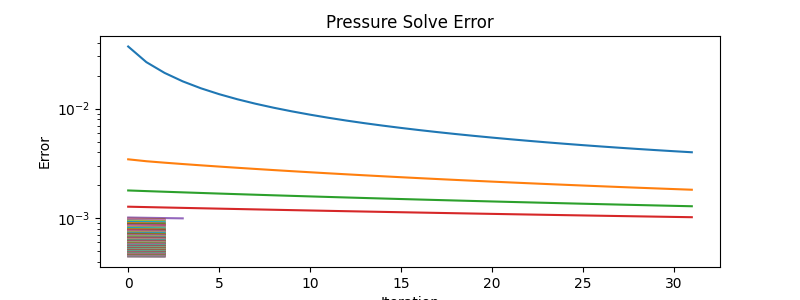

In [14]:
fig, axis = plt.subplots(1, 1, figsize=(8, 3), squeeze=False)

for i, (errors, pressures) in enumerate(trajectories):
    axis[0,0].plot(errors, label=f"Trajectory {i+1}")
axis[0,0].set_title("Pressure Solve Error")
axis[0,0].set_xlabel("Iteration")
axis[0,0].set_ylabel("Error")
axis[0,0].set_yscale('log')

In [15]:

markerSize = 4
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.velocities,
        "B":runningState.state.densities,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            mapping = Mapping.L2Norm,
            plotTitle = "velocities",
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
            # vMin=1e-10
        ),
        "B": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            # flipColorMap=True,
            markerSize = markerSize,
            midPoint = 1.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "densities",
            # vMin = 0.99,
            # vMax = 1.01
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'AB',
    figsize= (11,5),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)


RFBOutputContext()

In [16]:
config.dt = 1e-3
runningState = compressibleSystem.initializeNewState()
# runningState.state.velocities = torch.zeros_like(runningState.state.velocities, device=config.device, dtype=config.dtype)
adjacency = None

trajectories = []
adjacency = buildVerletList(
    runningState.state, 
    config.domain, verletScale = 1.4, supportMode = SupportScheme.SuperSymmetric,
    priorNeighborhood = adjacency,
    verbose = False)
rhoInit = computeDensities(runningState.state, config, schemeConfig, adjacency)


for i in tqdm(range(128)):

    adjacency = buildVerletList(
        runningState.state, 
        config.domain, verletScale = 1.4, supportMode = SupportScheme.SuperSymmetric,
        priorNeighborhood = adjacency,
        verbose = False)
    runningState.state.densities = computeDensities(runningState.state, config, schemeConfig, adjacency)
    runningState.state.pressures[:] = 0.0

    a_p, pressureB, errors, pressures = solveIncompressible(
            particles = runningState.state,
            config = config,
            schemeConfig = schemeConfig,
            adjacency = adjacency,
            dvdt = torch.zeros_like(runningState.state.velocities, device=config.device, dtype=config.dtype)
    )
    trajectories.append((errors,pressures))

    dx = config.dt**2 * a_p
    print(f"Position update: mean: {dx.mean().cpu().item():.6g}, min: {dx.min().cpu().item():.6g}, max: {dx.max().cpu().item():.6g}")

    # runningState.state.velocities = runningState.state.velocities + config.dt * a_p
    runningState.state.positions = runningState.state.positions + config.dt * config.dt * a_p


  0%|          | 0/128 [00:00<?, ?it/s]

Source term: 1.8772e-09, min: -0.156356, max: 0.180659
final Residual: 0.00225713, min: -0.0119601, max: 0.0174313
Position update: mean: 2.50111e-11, min: -0.0128572, max: 0.0116258
Source term: -2.88765e-10, min: -0.0147153, max: 0.0197629
final Residual: 1.77234e-05, min: -0.00776825, max: 0.00856925
Position update: mean: -4.26326e-12, min: -0.00154523, max: 0.00167389
Source term: -2.30557e-10, min: -0.00761534, max: 0.00845926
final Residual: 4.18899e-06, min: -0.00578232, max: 0.0064494
Position update: mean: 9.52127e-12, min: -0.00082465, max: 0.000831703
Source term: -5.92308e-11, min: -0.00573427, max: 0.00638484
final Residual: 2.23034e-06, min: -0.00472029, max: 0.00542874
Position update: mean: 7.95808e-13, min: -0.000542821, max: 0.000534138
Source term: -1.64732e-10, min: -0.00470478, max: 0.00538485
final Residual: 8.85101e-08, min: -0.00463094, max: 0.00532096
Position update: mean: -5.58664e-13, min: -5.56879e-05, max: 5.30572e-05
Source term: 3.94493e-11, min: -0.004

In [17]:
compressibleSystem.state.positions = runningState.state.positions.clone()
compressibleSystem.state.velocities[:,0] =  u_mag * torch.cos(ktgv * compressibleSystem.state.positions[:,0] + phaseShift_x) * torch.sin(ktgv *  compressibleSystem.state.positions[:,1] + phaseShift_y)
compressibleSystem.state.velocities[:,1] = -u_mag * torch.sin(ktgv * compressibleSystem.state.positions[:,0] + phaseShift_x) * torch.cos(ktgv * compressibleSystem.state.positions[:,1] + phaseShift_y)


In [18]:
from warpSPH.configurations import *
from sphWarpCore.enumTypes import ViscosityTerms
from sphWarpCore.kernels.wp_kernel import sphKernel_xi
from warpSPH.systems import *
from warpSPH.modules import *
from warpSPH.enumTypes import *
from sphWarpCore import *

from warpSPH.utils.timer import TimedBlock
from torch.profiler import profile, record_function, ProfilerActivity


def dfsph_step(
    system: CompSPHSystem,
    dt: float,
    config: SimulationConfig,
    schemeConfig: WeaklyCompressibleSPHConfig,
    verbose = False,        
):
    currentSystem = system#
    currentState = currentSystem.state
    adjacency = currentSystem.adjacency

    # 1. Compute adjacency
    # with TimedBlock('compute adjacency', use_cuda=True, device=config.device) as tb_adjacency:
    with record_function("[warpSPH] - [deltaSPH - 01] - compute adjacency"):
        verletScale = config.verletScale

        adjacency = buildVerletList(
            currentState, 
            config.domain, verletScale = verletScale, supportMode = SupportScheme.SuperSymmetric,
            priorNeighborhood = adjacency,
            verbose = False)
        currentSystem.adjacency = adjacency

    # 2. Compute density if density is none
    # with TimedBlock('compute density', use_cuda=True, device=config.device) as tb_density:
    with record_function("[warpSPH] - [deltaSPH - 02] - compute density"):
        # if currentState.densities is None:
            # print("Computing densities...")
        currentState.densities = computeDensities(currentState, config, schemeConfig, adjacency)
    # 3. Skipped mDBC density computation since no boundaries are present
    # with TimedBlock('compute mDBC density', use_cuda=True, device=config.device) as tb_mdbc:
    with record_function("[warpSPH] - [deltaSPH - 03] - compute mDBC density"):
        currentState.densities = computeMdbcDensity(currentState, config, schemeConfig, adjacency)

        # print(f'Fluid density stats: min={currentState.densities[currentState.kinds == 0].min().item()}, max={currentState.densities[currentState.kinds == 0].max().item()}, mean={currentState.densities[currentState.kinds == 0].mean().item()}')
        # print(f'Boundary density stats: min={currentState.densities[currentState.kinds == 1].min().item()}, max={currentState.densities[currentState.kinds == 1].max().item()}, mean={currentState.densities[currentState.kinds == 1].mean().item()}')
    # 4. enforce BCs
    with record_function("[warpSPH] - [deltaSPH - 06] - compute boundary velocities"):
        currentVelocities = currentState.velocities.clone()
        currentState.velocities = computeBoundaryVelocities(currentState, config, schemeConfig, adjacency)
    

    # with TimedBlock('enforce BCs', use_cuda=True, device=config.device) as tb_bcs:
    with record_function("[warpSPH] - [deltaSPH - 04] - enforce BCs"):
        enforceDirichlet(currentSystem, currentSystem.t, config.dt, config, schemeConfig)
    # 5. compute EOS (WC version)
    # with TimedBlock('compute EOS', use_cuda=True, device=config.device) as tb_eos:
    with record_function("[warpSPH] - [deltaSPH - 05] - compute EOS"):
        currentState.pressures = weaklyCompressibleEOS(currentState, schemeConfig)
    # 6. Skipped boundary velocity computation since no boundaries are present
    # with TimedBlock('compute boundary velocities', use_cuda=True, device=config.device) as tb_boundary_velocities:

    # 7. Compute Covariance Matrices for gradRho_l terms
    # Done in gradRhoL for now
    # 8. Run surface detection (only if free surface)
    # with TimedBlock('compute surface detection', use_cuda=True, device=config.device) as tb_surface:
    with record_function("[warpSPH] - [deltaSPH - 08] - compute surface detection"):
        fs, fsm, n, renormalizationState_, lMin = detectFreeSurface(currentState, config, schemeConfig, schemeConfig.surfaceDetectionConfig, adjacency, returnNormals = True) 
        currentState.surfaceIndicators = (fsm > 0.5).to(torch.int32)
        currentState.surfaceNormals = n
        currentState.surfaceLambdas = lMin

    #9. Compute gradRho and gradRhoL
    # with TimedBlock('compute gradRho', use_cuda=True, device=config.device) as tb_gradRho:
    with record_function("[warpSPH] - [deltaSPH - 09] - compute gradRho and gradRhoL"):
        if schemeConfig.diffusionParams.densityDiffusionTerm == DensityDiffusionScheme.denormalized or schemeConfig.diffusionParams.densityDiffusionTerm == DensityDiffusionScheme.denormalizedOnly:
            gradRho = computeGradRho(currentState, config, schemeConfig, adjacency)
        else:
            gradRho = None
    # with TimedBlock('compute gradRhoL', use_cuda=True, device=config.device) as tb_gradRhoL:
    with record_function("[warpSPH] - [deltaSPH - 09] - compute gradRhoL"):
        if schemeConfig.diffusionParams.densityDiffusionTerm == DensityDiffusionScheme.deltaSPH or schemeConfig.diffusionParams.densityDiffusionTerm == DensityDiffusionScheme.deltaOnly:
            gradRhoL = computeGradRhoL(currentState, config, schemeConfig, adjacency, L = renormalizationState_)
        else:
            gradRhoL = None


    # 10. Compute drhodt_diss
    # with TimedBlock('compute drhodt_diss', use_cuda=True, device=config.device) as tb_drhodt_diss:
    with record_function("[warpSPH] - [deltaSPH - 10] - compute drhodt_diss"):
        drhodt_diss = computeDensityDiffusion(currentState, config, schemeConfig, adjacency, gradRho, gradRhoL)

    # 11. Compute dvdt_diss
    # with TimedBlock('compute dvdt_diss', use_cuda=True, device=config.device) as tb_dvdt_diss:
    with record_function("[warpSPH] - [deltaSPH - 11] - compute dvdt_diss"):
        dvdt_diss = computeVelocityDiffusion(currentState, config, schemeConfig, adjacency)
    
    # 12. Compute drhodt
    # with TimedBlock('compute drhodt', use_cuda=True, device=config.device) as tb_drhodt:
    with record_function("[warpSPH] - [deltaSPH - 12] - compute drhodt"):
        drhodt = computeMomentum(currentState, config, schemeConfig, adjacency)

    # 14. Apply forcing
    # with TimedBlock('compute forcing', use_cuda=True, device=config.device) as tb_forcing:
    with record_function("[warpSPH] - [deltaSPH - 14] - compute forcing"):
        forcing = computeForcing(currentSystem, config.dt, currentSystem.t, config, schemeConfig)
        dvdt = forcing / currentState.masses.view(-1,1)


    # 15. Compute gravity
    # with TimedBlock('compute gravity', use_cuda=True, device=config.device) as tb_gravity:
    with record_function("[warpSPH] - [deltaSPH - 15] - compute gravity"):
        gravity = computeGravity(currentState, config, schemeConfig, adjacency)
        dvdt += gravity

    # Revert boundary velocity
    # with TimedBlock('compute mDBC no-pen shift', use_cuda=True, device=config.device) as tb_nopenshift:
    with record_function("[warpSPH] - [deltaSPH - 16] - compute mDBC no-pen shift"):
        nopenshift = computeMdbcNoPenShift(currentState, config, schemeConfig, adjacency)
        dvdt += nopenshift / dt
    # currentState.velocities = currentVelocities

    dvdt_pressure, pressure, errors, pressures = solveIncompressible(
        particles = currentState,
        config = config,
        schemeConfig = schemeConfig,
        adjacency = adjacency,
        dvdt = dvdt + dvdt_diss,
    )
    currentState.pressures = pressure



    # 16. build update
    # with TimedBlock('build update', use_cuda=True, device=config.device) as tb_update:
    with record_function("[warpSPH] - [deltaSPH - 16] - build update"):
        update = WeaklyCompressibleSystemUpdate(
            dxdt = currentState.velocities.clone(),
            dvdt = dvdt + dvdt_diss + dvdt_pressure,
            drhodt = drhodt + drhodt_diss,
            passive = torch.zeros(currentState.densities.shape, device=currentState.densities.device, dtype=torch.bool)
        )
    # update.drhodt = update.drhodt

    # 17. Enforce BCs on update
    # with TimedBlock('enforce updates', use_cuda=True, device=config.device) as tb_enforce:
    with record_function("[warpSPH] - [deltaSPH - 17] - enforce updates"):
        enforceUpdates(update, currentSystem, config.dt, currentSystem.t, config, schemeConfig)
        update.dxdt[currentState.kinds != 0,:] = 0.0
        update.dvdt[currentState.kinds != 0,:] = 0.0
        update.drhodt[currentState.kinds != 0] = 0.0

    # performanceDict = {
    #     'tb_adjacency': tb_adjacency,
    #     'tb_density': tb_density,
    #     'tb_mdbc': tb_mdbc,
    #     'tb_bcs': tb_bcs,
    #     'tb_eos': tb_eos,
    #     'tb_boundary_velocities': tb_boundary_velocities,
    #     'tb_surface': tb_surface,
    #     'tb_gradRho': tb_gradRho,
    #     'tb_gradRhoL': tb_gradRhoL,
    #     'tb_drhodt_diss': tb_drhodt_diss,
    #     'tb_dvdt_diss': tb_dvdt_diss,
    #     'tb_drhodt': tb_drhodt,
    #     'tb_dvdt': tb_dvdt,
    #     'tb_forcing': tb_forcing,
    #     'tb_gravity': tb_gravity,
    #     'tb_nopenshift': tb_nopenshift,
    #     'tb_update': tb_update,
    #     'tb_enforce': tb_enforce,
    # }

    # for key, tb in performanceDict.items():
    #     tb.cuda_ms = tb._start_event.elapsed_time(tb._end_event) if tb.use_cuda else None
    #     print(f"[{key}] CPU: {tb.cpu_ms:.3f} ms | CUDA: {tb.cuda_ms:.3f} ms, ratio {tb.cuda_ms / tb.cpu_ms if tb.cuda_ms is not None else 'N/A'}")

    return update, adjacency, currentState

In [19]:
runningState = compressibleSystem.initializeNewState()

runningState.state.densities = computeDensities(runningState.state, config, schemeConfig, None)

print(f"Initial densities: mean: {runningState.state.densities.mean().cpu().item():.6g}, min: {runningState.state.densities.min().cpu().item():.6g}, max: {runningState.state.densities.max().cpu().item():.6g}")

Initial densities: mean: 1.00106, min: 0.998573, max: 1.00359


In [20]:

markerSize = 2
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.velocities,
        "B":runningState.state.densities,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            mapping = Mapping.L2Norm,
            plotTitle = "velocities",
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
            # vMin=1e-10
        ),
        "B": PlottingOptions(
            colorMap = DivergingColorMap.RdBu,
            flipColorMap=True,
            markerSize = markerSize,
            midPoint = 1.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "densities",
            # vMin = 0.99,
            # vMax = 1.01
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'AB',
    figsize= (11,5),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)


RFBOutputContext()

In [21]:
schemeConfig.diffusionParams.inviscid = False
schemeConfig.diffusionParams.viscidNu = 0.01
schemeConfig.shiftProperties.active = False

In [22]:
config.dt = 1e-3

t_limit = 2.0
nSteps = int(t_limit / config.dt)

runningState = compressibleSystem.initializeNewState()

kes = []
priorStep = None
for i in (tq := tqdm(range(nSteps), leave = False)):
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    begin.record()
    result = integrator.function(
        state = runningState,
        f = dfsph_step,
        dt = config.dt,  
        config = config,
        schemeConfig = schemeConfig,
        verbose = False,
        # priorStep = priorStep
    )
    kes.append(torch.sum(0.5 * result.state.state.masses * torch.sum(result.state.state.velocities**2, dim=1)))
    # print('max_vel:', torch.linalg.norm(result.state.state.velocities, dim = -1).max())
    end.record()
    torch.cuda.synchronize()
    priorStep = result.stages[-1]
    timing = begin.elapsed_time(end)

    runningState = result.state
    runningState.state.densities = computeDensities(runningState.state, config, schemeConfig, None)

    if i % 10 == 0 and i > 0:
        plotter.updateQuantities(
            {
                "A": runningState.state.velocities,
                "B": runningState.state.densities,
            },
            newParticleState = runningState.state,
        )
        
    maxVel = torch.linalg.norm(runningState.state.velocities, dim = -1).max()
    tq.set_description(f"Step {i+1}/{nSteps}, time: {(i+1)*config.dt:8.4g}/{t_limit:8.4g} | max vel: {maxVel:.3g} | iter time: {timing:.3f} ms")
    # t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}'
    # break
    if torch.any(torch.isnan(runningState.state.velocities)):
        print("NaN detected in velocities, stopping simulation.")
        break



  0%|          | 0/2000 [00:00<?, ?it/s]

Module sphWarpCore.renorm.wp_covariance aa33657 load on device 'cuda:0' took 9.86 ms  (cached)
Module warpSPH.modules.deltaSPH.wp_densityDelta 87a4618 load on device 'cuda:0' took 7.10 ms  (cached)
Module warpSPH.modules.deltaSPH.wp_viscosityDelta 16e5aa1 load on device 'cuda:0' took 7.16 ms  (cached)
Source term: -6.31815e-11, min: -0.00252553, max: 0.00250623
final Residual: 1.14089e-08, min: -0.00251208, max: 0.00251287
Source term: -2.00657e-11, min: -0.00251742, max: 0.00251643
final Residual: 1.14653e-08, min: -0.00250625, max: 0.00251271
Source term: -4.94538e-12, min: -0.00249717, max: 0.00251731
final Residual: 1.0849e-08, min: -0.00249312, max: 0.00250637
Source term: 9.60085e-11, min: -0.00248943, max: 0.00251277
final Residual: 1.07677e-08, min: -0.00248963, max: 0.00249981
Source term: 4.63842e-11, min: -0.00248715, max: 0.00249919
final Residual: 1.01263e-08, min: -0.00248442, max: 0.002489
Source term: -2.77964e-11, min: -0.0024812, max: 0.00249061
final Residual: 9.8042

Something to note here is that the effective viscosity we measure here will be about half of the defined viscosity. This is an effect of the classic monaghan viscosity that only applies the viscosity to particles approaching each other. This is only true for (approximately) half the particles, thus we measure a viscosity that is half as well.

In [24]:
ts = np.arange(len(kes)) * config.dt#.cpu().item()
kineticEnergy = np.array([ke.cpu().item() for ke in kes])
E_k0 = kineticEnergy[0]

# Fit an effective viscosity from d/dt log(E_k) = -4 * (ktgv**2) * nu_eff
mask = (ts > 0) & (kineticEnergy > 0)
slope = np.polyfit(ts[mask], np.log(kineticEnergy[mask] / E_k0), 1)[0]
nu_eff = -slope / (4 * ktgv**2)
print(f"Estimated effective viscosity: {nu_eff:.6g}, actual viscosity: {schemeConfig.diffusionParams.viscidNu
:.6g}, diff: {abs(nu_eff - schemeConfig.diffusionParams.viscidNu
):.6g}")

Estimated effective viscosity: 0.0060298, actual viscosity: 0.01, diff: 0.0039702


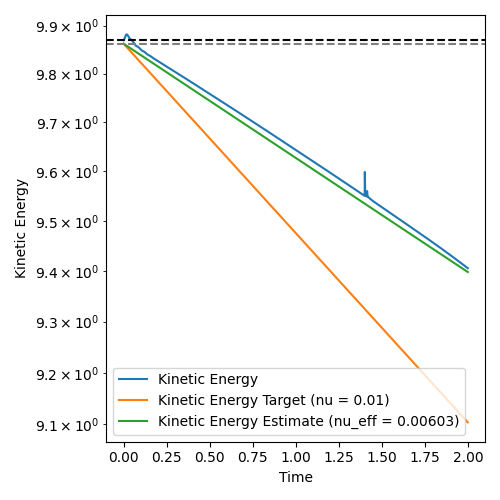

In [26]:
fig, axis = plt.subplots(1, 1, figsize=(5, 5), squeeze=False)

ts = np.arange(len(kes)) * config.dt#.cpu().item()
kineticEnergy = np.array([ke.cpu().item() for ke in kes])

nu = schemeConfig.diffusionParams.viscidNu

Ek0_theoretical = 0.25 * u_mag**2 * schemeConfig.fluid.restDensity * domainL**2

# For u ~ exp(-2*nu*k_mode^2*t), kinetic energy decays as exp(-4*nu*k_mode^2*t).
E_kestimate = ke0.sum().cpu().item() * np.exp(-4 * ts * (ktgv**2) * nu_eff)
E_ktarget = ke0.sum().cpu().item() * np.exp(-4 * ts * (ktgv**2) * nu)

axis[0,0].plot(ts, kineticEnergy, label='Kinetic Energy')
axis[0,0].plot(ts, E_ktarget, label=f'Kinetic Energy Target (nu = {nu:.4g})')
axis[0,0].plot(ts, E_kestimate, label=f'Kinetic Energy Estimate (nu_eff = {nu_eff:.4g})')
axis[0,0].set_xlabel('Time')
axis[0,0].set_ylabel('Kinetic Energy')
axis[0,0].legend()

axis[0,0].axhline(Ek0_theoretical, color='black', linestyle='--', label='Theoretical Initial Kinetic Energy')
axis[0,0].axhline(ke0.sum().cpu().item(), color='gray', linestyle='--', label='Initial Kinetic Energy from Simulation')

axis[0,0].set_yscale('log')

fig.tight_layout()

In [ ]:
# exportSimulationSystem(exportPath, f'finalState', scheme, runningState, exportAdjacency = False, stages = result.stages, exportStagesAdjacency = True, extraData = dict(**extraData, **{
#     'kineticEnergy': kineticEnergy,
#     'thermalEnergy': thermalEnergy,
#     'totalEnergy': totalEnergy,
#     'frame_num': i,
# }))

In [ ]:
# ffmpeg_cmd = "ffmpeg -y -loglevel error -hide_banner -framerate 50 -f image2 -pattern_type glob -i 'frame_*.png' -c:v libx264 -pix_fmt yuv420p -b:v 10M output.mp4"
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
# ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4  -vf "fps=50,scale=540:-1:flags=lanczos,palettegen" palette.png'
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
# ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4 -i palette.png -filter_complex "fps=25,scale=540:-1:flags=lanczos[x];[x][1:v]paletteuse" out.gif'
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)

# # now copy the output.mp4 and out.gif to the parent directory for easier access
# shutil.copy(f'{imagePath}/output.mp4', f'{exportPath}/output.mp4')
# shutil.copy(f'{imagePath}/out.gif', f'{exportPath}/out.gif');

We can run a convergence test to see how the viscosity scales as well:

In [43]:
nu_tests = np.logspace(-1, -5, base=10, num=10)
test_data = []

for nu in tqdm(nu_tests, desc="Testing viscosities", leave=False):
    t_limit = 2.0
    nSteps = int(t_limit / config.dt)

    runningState = compressibleSystem.initializeNewState()
    schemeConfig.diffusionParams.viscidNu = nu

    kes = []
    priorStep = None
    for i in (tq := tqdm(range(nSteps), leave = False)):
        begin = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)
        begin.record()
        result = integrator.function(
            state = runningState,
            f = fn,
            dt = config.dt,  
            config = config,
            schemeConfig = schemeConfig,
            verbose = False,
            priorStep = priorStep
        )
        kes.append(torch.sum(0.5 * result.state.state.masses * torch.sum(result.state.state.velocities**2, dim=1)))
        # print('max_vel:', torch.linalg.norm(result.state.state.velocities, dim = -1).max())
        end.record()
        torch.cuda.synchronize()
        priorStep = result.stages[-1]
        timing = begin.elapsed_time(end)

        runningState = result.state

        if i % 60 == 0 and i > 0:
            plotter.updateQuantities(
                {
                    "A": runningState.state.velocities,
                    "B": runningState.state.densities,
                },
                newParticleState = runningState.state,
            )
            
        maxVel = torch.linalg.norm(runningState.state.velocities, dim = -1).max()
        tq.set_description(f"Step {i+1}/{nSteps}, time: {(i+1)*config.dt:8.4g}/{t_limit:8.4g} | max vel: {maxVel:.3g} | iter time: {timing:.3f} ms")
        # t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}'
        # break
        if torch.any(torch.isnan(runningState.state.velocities)):
            print("NaN detected in velocities, stopping simulation.")
            breakts = np.arange(len(kes)) * config.dt.cpu().item()
    kineticEnergy = np.array([ke.cpu().item() for ke in kes])
    E_k0 = kineticEnergy[0]

    # Fit an effective viscosity from d/dt log(E_k) = -4 * (ktgv**2) * nu_eff
    mask = (ts > 0) & (kineticEnergy > 0)
    slope = np.polyfit(ts[mask], np.log(kineticEnergy[mask] / E_k0), 1)[0]
    nu_eff = -slope / (4 * ktgv**2)

    test_data.append({
        'nu': nu,
        'nu_eff': nu_eff,
        'nu_diff': abs(nu_eff - nu),
        'nu_rel_diff': abs(nu_eff - nu) / nu,
        'E_k0': E_k0,
        'kineticEnergy': kineticEnergy,
        'ts': ts,
    })


Testing viscosities:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1999 [00:00<?, ?it/s]

  0%|          | 0/1999 [00:00<?, ?it/s]

  0%|          | 0/1999 [00:00<?, ?it/s]

  0%|          | 0/1999 [00:00<?, ?it/s]

...

  0%|          | 0/1999 [00:00<?, ?it/s]

  0%|          | 0/1999 [00:00<?, ?it/s]

  0%|          | 0/1999 [00:00<?, ?it/s]

  0%|          | 0/1999 [00:00<?, ?it/s]

  0%|          | 0/1999 [00:00<?, ?it/s]

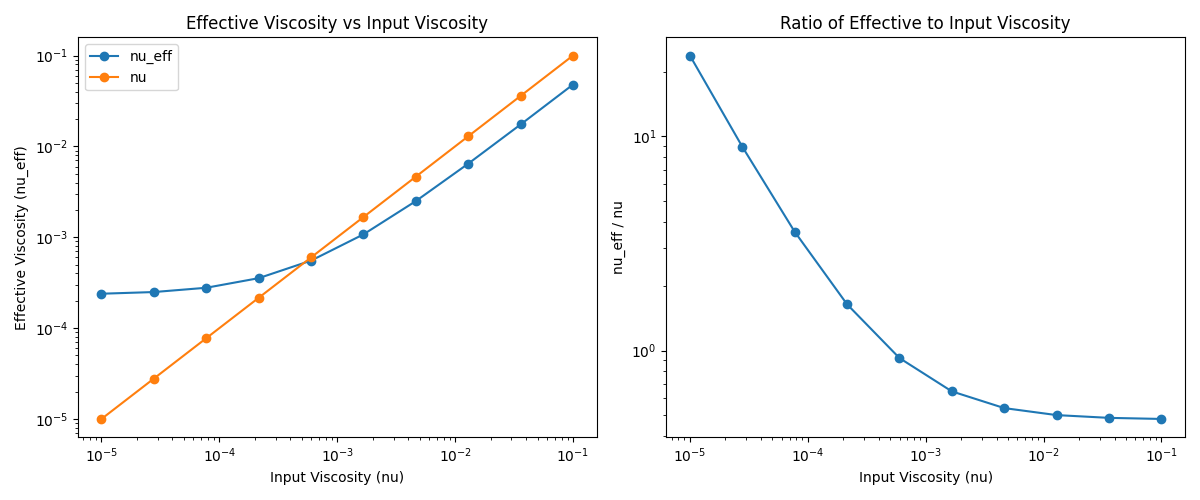

In [45]:
fig, axis = plt.subplots(1, 2, figsize=(12, 5), squeeze=False)

nus = np.array([data['nu'] for data in test_data])
nu_effs = np.array([data['nu_eff'] for data in test_data])
axis[0,0].loglog(nus, nu_effs, marker='o', label='nu_eff')
axis[0,0].loglog(nus, nus, marker='o', label='nu')
axis[0,0].set_xlabel('Input Viscosity (nu)')
axis[0,0].set_ylabel('Effective Viscosity (nu_eff)')
axis[0,0].set_title('Effective Viscosity vs Input Viscosity')
axis[0,0].legend()

axis[0,1].loglog(nus, nu_effs / nus, marker='o')
axis[0,1].set_xlabel('Input Viscosity (nu)')
axis[0,1].set_ylabel('nu_eff / nu')
axis[0,1].set_title('Ratio of Effective to Input Viscosity')

fig.tight_layout()

fig.savefig('nu_eff_vs_nu.png', dpi=300)
